In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("hosseinbadrnezhad/human-faces-dataset-male-female-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 1.05G/1.05G [00:11<00:00, 98.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/hosseinbadrnezhad/human-faces-dataset-male-female-classification/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/hosseinbadrnezhad/human-faces-dataset-male-female-classification/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/hosseinbadrnezhad/human-faces-dataset-male-female-classification/versions/1):
['men', 'women']


In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

# Output path for the split dataset
output_folder = "dataset_split"

# Split the dataset: 80% Train, 20% Val
# If you want 3 parts (Train/Val/Test), change ratio to (.8, .1, .1)
splitfolders.ratio(path, output=output_folder, seed=1337, ratio=(.8, .2), group_prefix=None, move=False)

print(f"Split completed! New data is located at: {output_folder}")

Copying files: 2000 files [00:05, 384.15 files/s]

Split completed! New data is located at: dataset_split


In [ ]:
import os

def count_files(directory):
    for root, dirs, files in os.walk(directory):
        if not dirs: # Only print leaf directories
            print(f"{root}: {len(files)} images")

print("Verifying image counts after split:")
count_files(output_folder)

Verifying image counts after split:
dataset_split/val/men: 146 images
dataset_split/val/women: 255 images
dataset_split/train/men: 581 images
dataset_split/train/women: 1018 images


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time
import os

# Check GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using device: cuda:0
Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


In [ ]:
# Data transformation and loading
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'dataset_split'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=2) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# Build DenseNet Model
model = models.densenet121(weights='IMAGENET1K_V1')
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
num_epochs = 10
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    for phase in ['train', 'val']:
        if phase == 'train': model.train()
        else: model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                if phase == 'train':
                    loss.backward()
                    optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc.item())
        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 188MB/s]


Epoch 1/10
train Loss: 0.2057 Acc: 0.9124
val Loss: 0.1861 Acc: 0.9377
Epoch 2/10
train Loss: 0.1477 Acc: 0.9368
val Loss: 0.2277 Acc: 0.9277
Epoch 3/10
train Loss: 0.1015 Acc: 0.9593
val Loss: 0.0845 Acc: 0.9726
Epoch 4/10
train Loss: 0.1092 Acc: 0.9518
val Loss: 0.1356 Acc: 0.9551
Epoch 5/10
train Loss: 0.0942 Acc: 0.9631
val Loss: 0.3426 Acc: 0.8878
Epoch 6/10
train Loss: 0.0919 Acc: 0.9619
val Loss: 0.1536 Acc: 0.9576
Epoch 7/10
train Loss: 0.0835 Acc: 0.9662
val Loss: 0.1321 Acc: 0.9401
Epoch 8/10
train Loss: 0.0788 Acc: 0.9706
val Loss: 0.1479 Acc: 0.9302
Epoch 9/10
train Loss: 0.0608 Acc: 0.9794
val Loss: 0.2455 Acc: 0.9202
Epoch 10/10
train Loss: 0.0683 Acc: 0.9737
val Loss: 0.2037 Acc: 0.9077


In [ ]:
# Summarize training results
best_val_acc = max(history['val_acc'])
print("--- Training Summary ---")
print(f"Final Training Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Final Validation Accuracy: {history['val_acc'][-1]:.4f}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

--- Training Summary ---
Final Training Accuracy: 0.9737
Final Validation Accuracy: 0.9077
Best Validation Accuracy: 0.9726


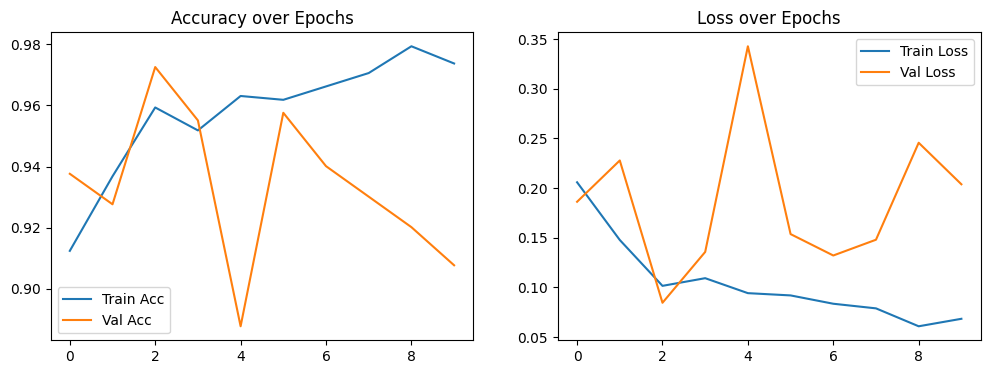

In [ ]:
# Visualize training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()